## Preprocessing and Metrics

The package only contains methods to simplify your code, so it doesn't cover all steps of machine learning process, but only those that save you lines of code.

In [1]:
#!pip install smltk==2.2.2

!pip install nltk
!pip install wordcloud
%pip install mlxtend --upgrade

import os
import sys
sys.path.insert(1, os.getcwd() + '/../../../')
print(os.getcwd())
print(sys.path)

import numpy as np
from smltk.data_processing import Ntk
nlp = Ntk()
from smltk.modeling import Modeling
mdl = Modeling()


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
/home/bilardi/github/bilardi/smltk/docs/source/usage
['/usr/lib64/python313.zip', '/home/bilardi/github/bilardi/smltk/docs/source/usage/../../../', '/usr/lib64/python3.13', '/usr/lib64/python3.13/lib-dynload', '', '/home/bilardi/github/bilardi/smltk/.env/lib64/python3.13/site-packages', '/home/bilardi/github/bilardi/smltk/.env/lib/python3.13/site-packages']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/bilardi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/bilardi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/bilardi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/bilardi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/bilardi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/bilardi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Example with nltk library

In [2]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/bilardi/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [3]:
docs_pos = [nltk.corpus.movie_reviews.raw(review) for review in nltk.corpus.movie_reviews.fileids(categories=["pos"])]
docs_neg = [nltk.corpus.movie_reviews.raw(review) for review in nltk.corpus.movie_reviews.fileids(categories=["neg"])]

#### Preprocessing

In [4]:
# data reduction
vocab_pos = nlp.create_vocab_from_docs(docs_pos)
#vocab_pos = nlp.create_vocab_from_docs(nltk.Text(nltk.corpus.movie_reviews.words(categories=["pos"])))
vocab_neg = nlp.create_vocab_from_docs(docs_neg)
#vocab_neg = nlp.create_vocab_from_docs(nltk.Text(nltk.corpus.movie_reviews.words(categories=["neg"])))
vocabs = {'pos': vocab_pos, 'neg': vocab_neg}

pos
(15790, 27557)


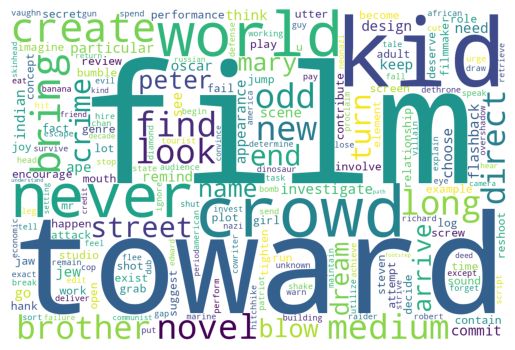

neg
(14667, 25746)


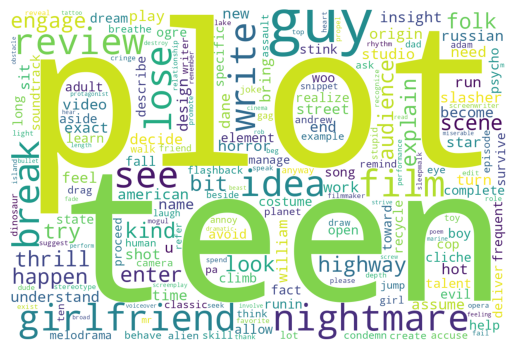

In [5]:
# distribution
for target in vocabs.keys():
  print(target)
  print(nlp.get_stats_vocab(vocabs[target], 2))
  nlp.create_words_cloud(nlp.create_words_map(vocabs[target]))

In [6]:
# data cleaning
vocabs_cleaned = nlp.get_vocabs_cleaned(vocabs)

In [7]:
# data wrangling
top_100_pos = nlp.get_words_top(vocabs_cleaned['pos'], 100)
top_100_neg = nlp.get_words_top(vocabs_cleaned['neg'], 100)

features = nlp.create_features_from_docs(docs_pos, 'pos', words_top = top_100_pos)
features.extend(nlp.create_features_from_docs(docs_neg, 'neg', words_top = top_100_neg))

In [8]:
# splitting
from nltk.sentiment.util import split_train_test
X_train, X_test = split_train_test(features)

#### Modeling

In [9]:
# fitting
classifier = nltk.NaiveBayesClassifier.train(X_train)

['pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'pos', 'neg', 'neg', 'neg', 'pos', 'pos', 'pos', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'neg', 'pos', 'neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'neg', 'neg', 'neg', 'pos', 'neg', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'neg', 'neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'neg', 'pos', 'neg', 'neg', 'neg', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'neg', 'pos', 'pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'pos', 'neg', 'pos', 'neg', 'neg', 'pos', 'pos', 'pos', 'neg', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'neg', 'neg', 'pos', 'neg', 'pos', 'pos', 'pos', 'neg', 'pos', 'pos', 'pos', 'pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'pos', 'pos', 'pos', 'neg', 'neg', 'neg', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'pos', 'neg', 'neg', 'pos', 'neg', 'neg', 'pos', 'pos'

array([[106,  76],
       [ 86, 132]])

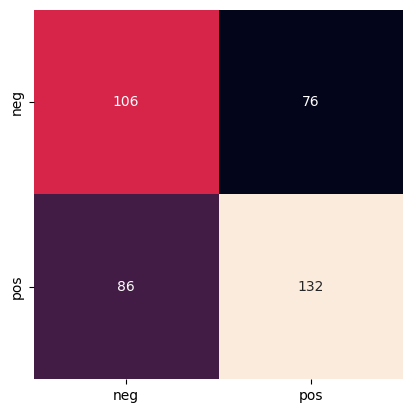

In [10]:
# testing
y_test, y_pred = mdl.prediction(classifier, 'classify', X_test)
mdl.create_confusion_matrix(y_test, y_pred)

In [11]:
mdl.get_classification_metrics({
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.18730944485936252,
 'ROC_AUC': 0.5939610847867728,
 'Accuracy': 0.595,
 'Precision': array([0.55208333, 0.63461538]),
 'Recall': array([0.58241758, 0.60550459]),
 'Fscore': array([0.56684492, 0.61971831]),
 'Support': array([182, 218])}

#### Prediction

In [12]:
classifier.classify(nlp.get_features(docs_pos[0]))

'pos'

In [13]:
classifier.classify(nlp.get_features(docs_neg[0]))

'neg'

### Example with sklearn library - wine dataset

In [14]:
from sklearn.datasets import load_wine
data = load_wine()

#### Preprocessing

In [15]:
# splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=5)

#### Modeling

In [16]:
# fitting
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=3)
model.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


[0 1 0 0 2 2 0 0 1 0 0 0 2 1 2 0 1 0 1 0 0 0 1 1 1 1 0 2 2 0 1 1 0 0 2 2]


array([[16,  0,  1],
       [ 2,  4,  5],
       [ 3,  1,  4]])

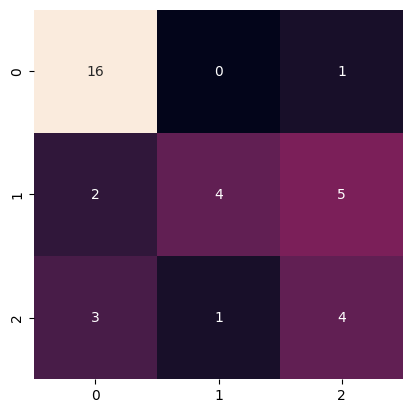

In [17]:
# testing
y_pred = model.predict(X_test)
mdl.create_confusion_matrix(y_test, y_pred)

In [18]:
mdl.get_classification_metrics({
    "model": model,
    "X_train": np.array(X_train),
    "y_train": np.array(y_train),
    "X_test": np.array(X_test),
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': np.float64(0.7443055555555557),
 'Bias': np.float64(0.3698465277777778),
 'Variance': np.float64(0.3744590277777778),
 'MCC': 0.4802259242337604,
 'ROC_AUC': 0,
 'Accuracy': 0.6666666666666666,
 'Precision': array([0.76190476, 0.8       , 0.4       ]),
 'Recall': array([0.94117647, 0.36363636, 0.5       ]),
 'Fscore': array([0.84210526, 0.5       , 0.44444444]),
 'Support': array([17, 11,  8])}

#### Management

In [19]:
mdl.save_model(model, 'model.pkl')
model.score(X_test, y_test)

0.6111111111111112

In [20]:
model_resumed = mdl.resume_model('model.pkl')
model_resumed.score(X_test, y_test)

0.6111111111111112

### Example with sklearn library - text dataset

In [21]:
!if [ ! -f 'sentiment.zip' ]; then curl https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip --output sentiment.zip; fi
!if [ ! -d 'sentiment labelled sentences' ]; then unzip 'sentiment.zip'; fi
!ls -ltr 'sentiment labelled sentences'

total 208
-rw-r--r--. 1 bilardi bilardi 58226 30 nov  2024 amazon_cells_labelled.txt
-rw-r--r--. 1 bilardi bilardi  1070 30 nov  2024 readme.txt
-rw-r--r--. 1 bilardi bilardi 61320 30 nov  2024 yelp_labelled.txt
-rw-r--r--. 1 bilardi bilardi 85285 30 nov  2024 imdb_labelled.txt


In [22]:
!cat 'sentiment labelled sentences/amazon_cells_labelled.txt' | head -n 5

So there is no way for me to plug it in here in the US unless I go by a converter.	0
Good case, Excellent value.	1
Great for the jawbone.	1
Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!	0
The mic is great.	1


In [23]:
import pandas as pd
data = pd.read_csv(
  'sentiment labelled sentences/amazon_cells_labelled.txt',
  sep='\t',
  names=['text', 'sentiment']
)

#### Preprocessing

(609, 1464)


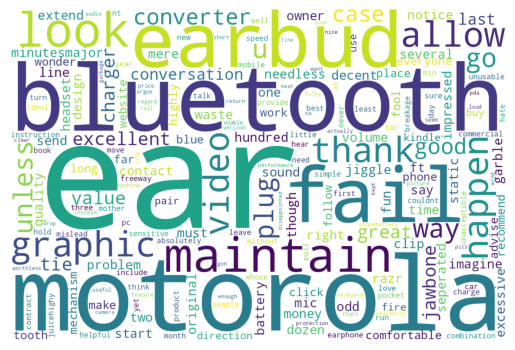

In [24]:
# distribution
vocabulary = nlp.create_vocab_from_docs(data['text'])
print(nlp.get_stats_vocab(vocabulary, 2))
nlp.create_words_cloud(nlp.create_words_map(vocabulary))

In [25]:
# data cleaning
data['text_cleaned'] = data['text'].apply(nlp.get_doc_cleaned)

In [26]:
# distribution
vocabulary = nlp.create_vocab_from_docs(data['text_cleaned'])
print(nlp.get_stats_vocab(vocabulary, 2))
nlp.create_words_cloud(nlp.create_words_map(vocabulary), is_test = True)

(602, 1451)


#### Modeling by vectors

In [27]:
# splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data['text_cleaned'], data['sentiment'], test_size=0.2, random_state=3)

In [28]:
# vectorization
X_vect_train = nlp.vectorize_docs(X_train, is_lemma = True)
X_vect_test = nlp.vectorize_docs(X_test, is_lemma = True, is_test = True)

In [29]:
# fitting
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=3)
model.fit(X_vect_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


642    0
762    1
909    1
199    0
586    1
      ..
164    0
782    0
575    0
992    0
713    1
Name: sentiment, Length: 200, dtype: int64


array([[85, 20],
       [29, 66]])

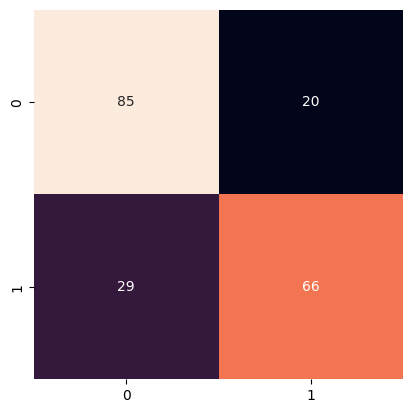

In [30]:
# testing
y_pred = model.predict(X_vect_test)
mdl.create_confusion_matrix(y_test, y_pred, is_test = False)

In [31]:
mdl.get_classification_metrics({
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.5086392633425091,
 'ROC_AUC': 0.7521303258145364,
 'Accuracy': 0.755,
 'Precision': array([0.74561404, 0.76744186]),
 'Recall': array([0.80952381, 0.69473684]),
 'Fscore': array([0.77625571, 0.72928177]),
 'Support': array([105,  95])}

#### Modeling by vectors and tokenization

In [32]:
# vectorization
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer = 'word', tokenizer = nlp) #, ngram_range = (1, 2)
X_vect_train = vectorizer.fit_transform(X_train)
X_vect_test = vectorizer.transform(X_test)

/home/bilardi/github/bilardi/smltk/.env/lib64/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [33]:
# fitting
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=3)
model.fit(X_vect_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


642    0
762    1
909    1
199    0
586    1
      ..
164    0
782    0
575    0
992    0
713    1
Name: sentiment, Length: 200, dtype: int64


array([[85, 20],
       [29, 66]])

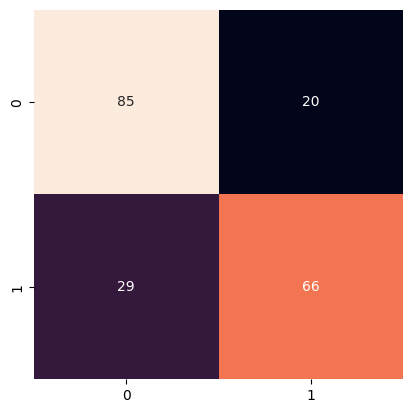

In [34]:
# testing
y_pred = model.predict(X_vect_test)
mdl.create_confusion_matrix(y_test, y_pred, is_test = False)

In [35]:
mdl.get_classification_metrics({
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.5086392633425091,
 'ROC_AUC': 0.7521303258145364,
 'Accuracy': 0.755,
 'Precision': array([0.74561404, 0.76744186]),
 'Recall': array([0.80952381, 0.69473684]),
 'Fscore': array([0.77625571, 0.72928177]),
 'Support': array([105,  95])}

#### Modeling by features

In [36]:
# data wrangling
top_100 = nlp.get_words_top(vocabulary, 100)

features = nlp.get_features_from_docs(data.text, words_top = top_100)
features_df = pd.DataFrame.from_dict(features, orient='columns')
data = pd.concat([data, features_df], axis='columns')

In [37]:
# splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data[['words_top', 'neg', 'neu', 'pos', 'compound']], data['sentiment'], test_size=0.2, random_state=3)

In [38]:
# fitting
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=3)
model.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


642    0
762    1
909    1
199    0
586    1
      ..
164    0
782    0
575    0
992    0
713    1
Name: sentiment, Length: 200, dtype: int64


array([[98,  7],
       [34, 61]])

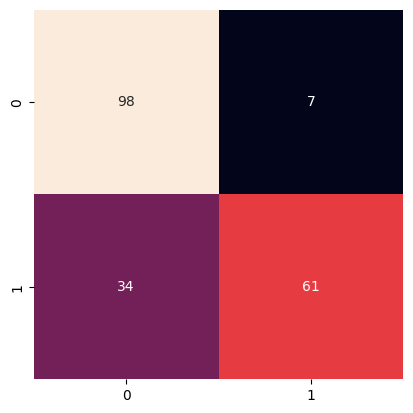

In [39]:
# testing
y_pred = model.predict(X_test)
mdl.create_confusion_matrix(y_test, y_pred, is_test = False)

In [40]:
mdl.get_classification_metrics({
    "model": model,
    "X_train": np.array(X_train),
    "y_train": np.array(y_train),
    "X_test": np.array(X_test),
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': np.float64(0.23532499999999998),
 'Bias': np.float64(0.153603875),
 'Variance': np.float64(0.081721125),
 'MCC': 0.6066162196580951,
 'ROC_AUC': 0.787719298245614,
 'Accuracy': 0.795,
 'Precision': array([0.74242424, 0.89705882]),
 'Recall': array([0.93333333, 0.64210526]),
 'Fscore': array([0.82700422, 0.74846626]),
 'Support': array([105,  95])}

#### Modeling by vectors and features

In [41]:
# data reduction
features_mix = data[['text_cleaned', 'words_top', 'neg', 'neu', 'pos', 'compound']].to_dict(orient="records")

In [42]:
# splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_mix, data['sentiment'], test_size=0.2, random_state=3)

In [43]:
# vectorization
X_vect_train = nlp.vectorize_docs(X_train)
X_vect_test = nlp.vectorize_docs(X_test, is_test = True)

In [44]:
# fitting
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=3)
model.fit(X_vect_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


642    0
762    1
909    1
199    0
586    1
      ..
164    0
782    0
575    0
992    0
713    1
Name: sentiment, Length: 200, dtype: int64


array([[95, 10],
       [31, 64]])

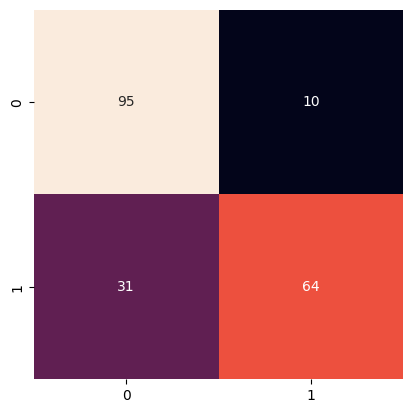

In [45]:
# testing
y_pred = model.predict(X_vect_test)
mdl.create_confusion_matrix(y_test, y_pred, is_test = False)

In [46]:
mdl.get_classification_metrics({
    "y_test": np.array(y_test),
    "y_pred": y_pred
})

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.5982989333106916,
 'ROC_AUC': 0.7892230576441103,
 'Accuracy': 0.795,
 'Precision': array([0.75396825, 0.86486486]),
 'Recall': array([0.9047619 , 0.67368421]),
 'Fscore': array([0.82251082, 0.75739645]),
 'Support': array([105,  95])}

### Example with sklearn library - pipeline

In [47]:
# splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['sentiment'], test_size=0.2, random_state=3)

In [48]:
# data preparation
vectorizer = CountVectorizer()
X_vect_train = vectorizer.fit_transform(X_train) 
X_vect_test = vectorizer.transform(X_test)
# modeling
model = SGDClassifier(random_state=3)
model.fit(X_vect_train, y_train) # training
mdl.scoring(model, X_vect_test, y_test) # testing

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.5887959168743058,
 'ROC_AUC': 0.7942355889724311,
 'Accuracy': 0.795,
 'Precision': array([0.80188679, 0.78723404]),
 'Recall': array([0.80952381, 0.77894737]),
 'Fscore': array([0.8056872 , 0.78306878]),
 'Support': array([105,  95])}

In [49]:
from sklearn.pipeline import Pipeline
# data preparation
pipeline = Pipeline([
    ('count', CountVectorizer()),
    ('class', SGDClassifier(random_state=3))
])
# modeling
mdl.modeling(pipeline, X_train, y_train, X_test, y_test)

{'Loss': 0,
 'Bias': 0,
 'Variance': 0,
 'MCC': 0.5887959168743058,
 'ROC_AUC': 0.7942355889724311,
 'Accuracy': 0.795,
 'Precision': array([0.80188679, 0.78723404]),
 'Recall': array([0.80952381, 0.77894737]),
 'Fscore': array([0.8056872 , 0.78306878]),
 'Support': array([105,  95])}